In [6]:
!pip install pandas matplotlib seaborn

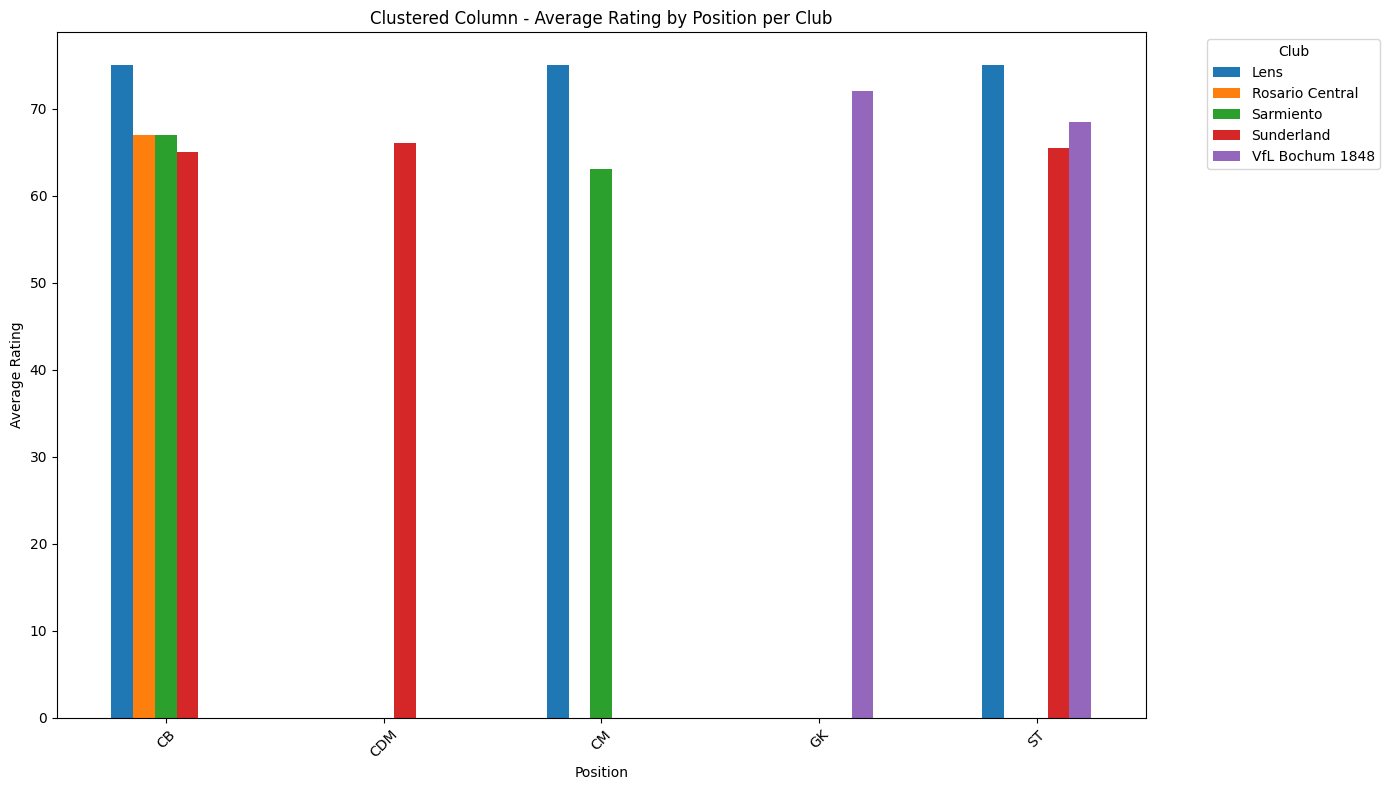

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("/content/clean_players.csv")

df = df[['club_name', 'player_positions', 'overall']]
df = df.dropna()

df = df.sample(n=1000, random_state=42)

df['position'] = df['player_positions'].apply(lambda x: x.split(',')[0])

top_clubs = df['club_name'].value_counts().head(5).index
top_positions = df['position'].value_counts().head(6).index

df_filtered = df[
    (df['club_name'].isin(top_clubs)) &
    (df['position'].isin(top_positions))
]

pivot = pd.pivot_table(
    df_filtered,
    values='overall',
    index='position',
    columns='club_name',
    aggfunc='mean'
)

pivot.plot(
    kind='bar',
    figsize=(14, 8)
)

plt.title('Clustered Column - Average Rating by Position per Club')
plt.xlabel('Position')
plt.ylabel('Average Rating')
plt.legend(title='Club', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
!pip install pandas plotly

In [9]:
import pandas as pd
import plotly.express as px
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("/content/clean_players.csv")

df = df[['club_name', 'player_positions', 'overall']].dropna()

df = df.sample(n=1000, random_state=42)

df['position'] = df['player_positions'].apply(lambda x: x.split(',')[0])

top_clubs = df['club_name'].value_counts().head(5).index
top_positions = df['position'].value_counts().head(6).index

df_filtered = df[
    (df['club_name'].isin(top_clubs)) &
    (df['position'].isin(top_positions))
]

grouped = df_filtered.groupby(['position', 'club_name'])['overall'].mean().reset_index()

fig = px.bar(
    grouped,
    x='position',
    y='overall',
    color='club_name',
    barmode='group',
    title='Clustered Column - Average Rating by Position per Club'
)

fig.update_layout(
    xaxis_title="Position",
    yaxis_title="Average Rating",
    legend_title="Club"
)

fig.show()